In [2]:
import pandas as pd
import re 
import seaborn as sns 
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
data = pd.read_csv("Cars Datasets 2025.csv", encoding = "cp1252")
data.head(10)

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm
5,BMW,Mclaren 720s,V8,"3,994 cc",710 hp,341 km/h,2.9 sec,"$499,000",Petrol,2,770 Nm
6,ASTON MARTIN,VANTAGE F1,V8,"3,982 cc",656 hp,314 km/h,3.6 sec,"$193,440",Petrol,2,685 Nm
7,BENTLEY,Continental GT Azure,V8,"3,996 cc",550 hp,318 km/h,4.0 sec,"$311,000",Petrol,4,900 Nm
8,LAMBORGHINI,VENENO ROADSTER,V12,"6,498 cc",750 hp,356 km/h,2.9 sec,"$4,500,000",Petrol,2,690 Nm
9,FERRARI,F8 TRIBUTO,V8,"3,900 cc",710 hp,340 km/h,2.9 sec,"$280,000",Petrol,2,770 Nm


<Axes: xlabel='Company Names'>

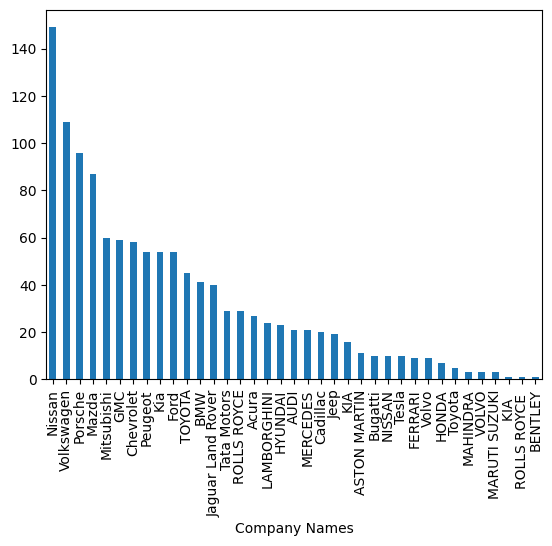

In [4]:
plot1 = data['Company Names'].value_counts()
plot1.plot(kind='bar')

In [5]:
slash_count = data["Cars Prices"].str.contains("€", na=False).sum()
print("Rows with '€' in Cars Prices:", slash_count)

Rows with '€' in Cars Prices: 1


In [6]:
data = data[~data["Cars Prices"].str.contains("/", na=False)]
data = data[~data["Cars Prices"].str.contains("€", na=False)]

In [7]:
def clean_prices(values):
    
    values = values.replace("$", "").replace(",","").replace("–", "-").replace("—", "-").replace("−", "-")

    if "-" in values:
        low, high = values.split("-")
        low, high = int(low), int(high)

        avg = int(low)+int(high)/2
        return avg
    else:
        return int(values)

price_data = data['Cars Prices'].apply(clean_prices)
    

In [8]:
def clean_torque(value):
    # Extract first numeric part (handles integers and decimals)
    match = re.search(r"\d+\.?\d*", str(value))
    if match:
        return float(match.group())  # use float for safety
    return None

data["Torque"] = data["Torque"].apply(clean_torque)


In [9]:
data['Cars Prices'] = price_data
data

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,1100000.0,plug in hyrbrid,2,800.0
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,460000.0,Petrol,5,900.0
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,19500.0,Petrol,5,100.0
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,161000.0,Petrol,4,900.0
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,253290.0,Petrol,2,560.0
...,...,...,...,...,...,...,...,...,...,...,...
1212,Mazda,787B (Race Car),2.6L Wankel Rotary Engine,"2,620 cc",700 hp,320 km/h,3.5 sec,8500000.0,Petrol,1,500.0
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,67590.0,Hybrid (Gas + Electric),5,239.0
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,50000.0,Hybrid,7,630.0
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169 – 196 hp,190 km/h,8.0 – 9.2 sec,39777.5,Gas / Hybrid,5,190.0


In [10]:

def clean_hp(value):
    # Extract first numeric part (integer or decimal)
    match = re.search(r"\d+\.?\d*", str(value))
    if match:
        return float(match.group())
    return None

# Apply to HorsePower column
data["HorsePower"]= data["HorsePower"].apply(clean_hp)

def clean_numeric(value):
    # Find the first number in the string (supports decimals too)
    match = re.search(r"\d+(\.\d+)?", str(value))
    if match:
        return float(match.group())
    return None  # if no number found

data['CC/Battery Capacity'] = data['CC/Battery Capacity'].apply(clean_numeric)
data['HorsePower'] = data['HorsePower'].apply(clean_numeric)
data['Performance(0 - 100 )KM/H'] = data['Performance(0 - 100 )KM/H'].apply(clean_numeric)
data['Total Speed'] = data['Total Speed'].apply(clean_numeric)

In [13]:
data

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990.0,963.0,340.0,2.5,1100000.0,plug in hyrbrid,2,800.0
1,ROLLS ROYCE,PHANTOM,V12,6749.0,563.0,250.0,5.3,460000.0,Petrol,5,900.0
2,Ford,KA+,1.2L Petrol,1.0,70.0,165.0,10.5,19500.0,Petrol,5,100.0
3,MERCEDES,GT 63 S,V8,3.0,630.0,250.0,3.2,161000.0,Petrol,4,900.0
4,AUDI,AUDI R8 Gt,V10,5.0,602.0,320.0,3.6,253290.0,Petrol,2,560.0
...,...,...,...,...,...,...,...,...,...,...,...
1212,Mazda,787B (Race Car),2.6L Wankel Rotary Engine,2.0,700.0,320.0,3.5,8500000.0,Petrol,1,500.0
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487.0,240.0,180.0,7.6,67590.0,Hybrid (Gas + Electric),5,239.0
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393.0,326.0,180.0,6.8,50000.0,Hybrid,7,630.0
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987.0,169.0,190.0,8.0,39777.5,Gas / Hybrid,5,190.0


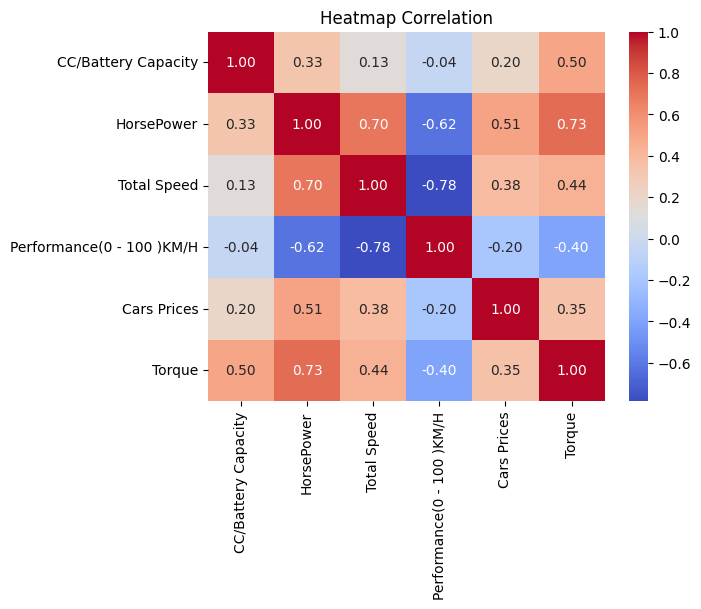

In [12]:
sns.heatmap(data= data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap Correlation")
plt.show()

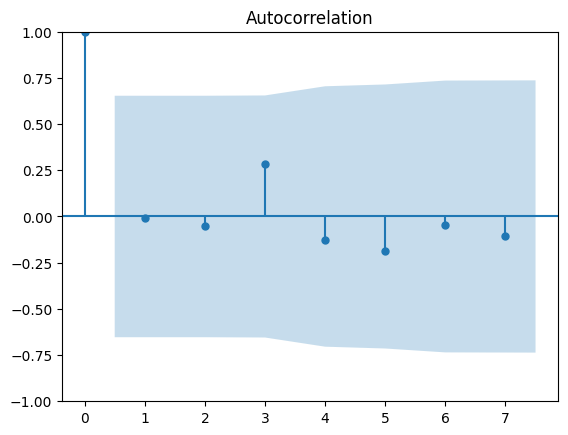

In [7]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Sample data
sales = [20, 22, 25, 27, 28, 39, 29, 23, 44]
series = pd.Series(sales)

# Plot autocorrelation
plot_acf(series, lags=7)
plt.show()


In [2]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Example time series data
data = [112,118,132,129,121,135,148,148,136,119,104,118]
series = pd.Series(data)

# Fit two models
model1 = ARIMA(series, order=(1,0,0)).fit()
model2 = ARIMA(series, order=(2,0,0)).fit()

print("AIC of Model 1 (AR(1)):", model1.aic)
print("AIC of Model 2 (AR(2)):", model2.aic)


AIC of Model 1 (AR(1)): 96.74409769298362
AIC of Model 2 (AR(2)): 92.20047029200869
